<a href="https://colab.research.google.com/github/Melainin2/Melainin2/blob/main/INSEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


In [3]:
from google.colab import files
files.upload()  # Permet de télécharger kaggle.json depuis ton PC.

import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"


Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [4]:
import pandas as pd

# Charger les données depuis le fichier Titanic-Dataset.csv
train = pd.read_csv('/content/Titanic-Dataset.csv')

# Afficher les premières lignes du dataset pour vérifier le contenu
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Traitement des valeurs manquantes
train['Age'].fillna(train['Age'].median(), inplace=True)  # Remplir les valeurs manquantes dans "Age" avec la médiane
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)  # Remplir les valeurs manquantes dans "Embarked" avec la valeur la plus fréquente

# Encodage des variables catégorielles
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})  # 'male' -> 0, 'female' -> 1
train['Embarked'] = train['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})  # 'C' -> 0, 'Q' -> 1, 'S' -> 2

# Extraire les caractéristiques (X) et la cible (y)
X = train.drop(['Survived', 'Name', 'Ticket', 'Cabin'], axis=1)  # Supprimer les colonnes non pertinentes
y = train['Survived']  # La cible est la colonne "Survived"

# Afficher les premières lignes des caractéristiques pour vérifier
X.head()


<ipython-input-5-f004facb8bcf>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)  # Remplir les valeurs manquantes dans "Age" avec la médiane
<ipython-input-5-f004facb8bcf>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,0,22.0,1,0,7.2500,2
1,2,1,1,38.0,1,0,71.2833,0
2,3,3,1,26.0,0,0,7.9250,2
3,4,1,1,35.0,1,0,53.1000,2
4,5,3,0,35.0,0,0,8.0500,2


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Séparer les données en un ensemble d'entraînement et de test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer le modèle de régression logistique
model = LogisticRegression(max_iter=500)



# Entraîner le modèle avec les données d'entraînement
model.fit(X_train, y_train)

# Prédire les résultats sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluer la performance du modèle
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Afficher les résultats
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix: \n{conf_matrix}")


Accuracy: 0.8100558659217877
Confusion Matrix: 
[[90 15]
 [19 55]]


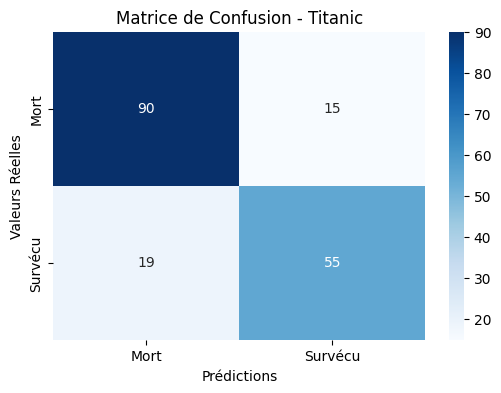

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Recalculer la matrice de confusion (au cas où)
conf_matrix = confusion_matrix(y_test, y_pred)

# Tracer la heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Mort', 'Survécu'], yticklabels=['Mort', 'Survécu'])
plt.xlabel("Prédictions")
plt.ylabel("Valeurs Réelles")
plt.title("Matrice de Confusion - Titanic")
plt.show()


In [10]:
import joblib

# Sauvegarder le modèle dans un fichier
joblib.dump(model, 'titanic_model.pkl')

print("✅ Modèle sauvegardé sous le nom : titanic_model.pkl")


✅ Modèle sauvegardé sous le nom : titanic_model.pkl


In [11]:
# Recharger le modèle depuis le fichier
loaded_model = joblib.load('titanic_model.pkl')

# Tester une prédiction avec le modèle chargé
y_loaded_pred = loaded_model.predict(X_test)
